# Merchant features

The ranking needs **one row per merchant**. This notebook turns the 13.5 million transactions in
`curated/transactions_fraud.parquet` into three tables:

| Output | What it holds |
|---|---|
| `curated/merchant_daily.parquet` | sales, BNPL revenue and expected fraud for every merchant and day (used by `forecast.ipynb`) |
| `curated/merchant_features.parquet` | one row per merchant: size, customers, order value, fraud, growth, stability and customer demographics |
| `curated/sa2_summary.parquet` | consumers, sales and fraud for every SA2 (used for the maps in `summary.ipynb`) |

Throughout, **sales** is what customers paid the merchant, **revenue** is the BNPL firm's share of it
(`take_rate` x sales), and **expected fraud** is the sales weighted by `fraud_probability` (`fraud.ipynb`).

The second half checks which features actually tell merchants apart. Three findings shape the ranking:
1. Merchants differ enormously in **size**, **take rate** and **fraud**.
2. They all **grow at about the same rate**, with the **same seasonal pattern**.
3. Their **customers look the same**: the same income, gender mix and locations.

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, StrMethodFormatter
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

Settings and helper functions used throughout this notebook: file paths, key dates, chart colours and formatting.

In [2]:
# Files
EXTERNAL = Path("external_data")       # ABS data
CURATED = Path("curated")              # files the notebooks pass to each other
PLOTS = Path("plots")                  # charts, saved for the presentation
TRANSACTIONS_FRAUD = CURATED / "transactions_fraud.parquet"  # from fraud.ipynb
MERCHANT_DAILY = CURATED / "merchant_daily.parquet"          # from features.ipynb
MERCHANT_FEATURES = CURATED / "merchant_features.parquet"    # from features.ipynb
SA2_SUMMARY = CURATED / "sa2_summary.parquet"                # from features.ipynb

# Key dates
FIRST_DAY = "2021-02-28"        # first day of the transactions
LAST_DAY = "2022-10-26"         # last day of the transactions
SECOND_SNAPSHOT = "2021-08-28"  # first day of the second snapshot: the fraud files flag ~6x more from here
LAST_12M_START = "2021-10-27"   # the last 12 months of data: 27 Oct 2021 - 26 Oct 2022

# The 25 merchant categories, grouped into 5 segments by what the customer is buying (see ranking.ipynb)
SEGMENTS = {
    "Technology & Media": [
        "computers, computer peripheral equipment, and software",
        "computer programming, data processing, and integrated systems design services",
        "telecom",
        "cable, satellite, and other pay television and radio services",
        "digital goods: books, movies, music",
    ],
    "Home & Garden": [
        "furniture, home furnishings and equipment shops, and manufacturers, except appliances",
        "lawn and garden supply outlets, including nurseries",
        "florists supplies, nursery stock, and flowers",
        "equipment, tool, furniture, and appliance rental and leasing",
    ],
    "Fashion & Personal Care": [
        "shoe shops",
        "jewelry, watch, clock, and silverware shops",
        "watch, clock, and jewelry repair shops",
        "opticians, optical goods, and eyeglasses",
        "health and beauty spas",
    ],
    "Hobbies, Arts & Gifts": [
        "artist supply and craft shops",
        "art dealers and galleries",
        "antique shops - sales, repairs, and restoration services",
        "hobby, toy and game shops",
        "music shops - musical instruments, pianos, and sheet music",
        "gift, card, novelty, and souvenir shops",
        "books, periodicals, and newspapers",
        "stationery, office supplies and printing and writing paper",
    ],
    "Outdoor & Auto": [
        "tent and awning shops",
        "bicycle shops - sales and service",
        "motor vehicle supplies and new parts",
    ],
}
CATEGORY_TO_SEGMENT = {category: segment for segment, categories in SEGMENTS.items() for category in categories}

# Short names for charts and tables (the full category names are up to 85 characters long)
CATEGORY_LABELS = {
    "computers, computer peripheral equipment, and software": "Computers & software",
    "computer programming, data processing, and integrated systems design services": "IT services",
    "telecom": "Telecom",
    "cable, satellite, and other pay television and radio services": "Pay TV & radio",
    "digital goods: books, movies, music": "Digital goods",
    "furniture, home furnishings and equipment shops, and manufacturers, except appliances": "Furniture",
    "lawn and garden supply outlets, including nurseries": "Lawn & garden",
    "florists supplies, nursery stock, and flowers": "Florists",
    "equipment, tool, furniture, and appliance rental and leasing": "Equipment rental",
    "shoe shops": "Shoe shops",
    "jewelry, watch, clock, and silverware shops": "Jewellery shops",
    "watch, clock, and jewelry repair shops": "Watch & jewellery repair",
    "opticians, optical goods, and eyeglasses": "Opticians",
    "health and beauty spas": "Health & beauty spas",
    "artist supply and craft shops": "Artist supply & craft",
    "art dealers and galleries": "Art dealers",
    "antique shops - sales, repairs, and restoration services": "Antiques",
    "hobby, toy and game shops": "Hobby, toys & games",
    "music shops - musical instruments, pianos, and sheet music": "Music shops",
    "gift, card, novelty, and souvenir shops": "Gifts & souvenirs",
    "books, periodicals, and newspapers": "Books & newspapers",
    "stationery, office supplies and printing and writing paper": "Stationery & office",
    "tent and awning shops": "Tents & awnings",
    "bicycle shops - sales and service": "Bicycle shops",
    "motor vehicle supplies and new parts": "Motor vehicle parts",
}

# Chart colours
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE = "#2a78d6"            # the main colour
ORANGE = "#eb6834"          # what loses money
CONTEXT_GREY = "#b9b8b2"    # everything that isn't the point of the chart


def spark_session():
    """The same Spark settings as etl.ipynb, with the console progress bars and INFO logs turned off."""
    # pyspark 4.2 warns that pandas 3 isn't officially supported yet. Data only moves between pandas and Spark as
    # small aggregates or through parquet files, which works fine.
    warnings.filterwarnings("ignore", message="PySpark does not yet fully support pandas")
    spark = (SparkSession.builder.appName("Project 2")
             .config("spark.sql.repl.eagerEval.enabled", True)
             .config("spark.sql.parquet.cacheMetadata", "true")
             .config("spark.sql.session.timeZone", "Etc/UTC")
             .config("spark.driver.memory", "4g")
             .config("spark.executor.memory", "2g")
             .config("spark.ui.showConsoleProgress", "false")
             .getOrCreate())
    spark.sparkContext.setLogLevel("ERROR")
    return spark


def apply_style():
    """Quiet, consistent chart defaults (the same palette as etl.ipynb). Also stops Jupyter reading the dollar
    signs in tables as maths formulas."""
    pd.set_option("display.html.use_mathjax", False)
    pd.set_option("styler.html.mathjax", False)
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.titlelocation": "left", "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "axes.axisbelow": True,
        "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_SECONDARY, "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False, "legend.labelcolor": INK, "font.size": 10,
        "lines.linewidth": 2, "lines.solid_capstyle": "round",
    })


def money(x, _=None):
    """$950, $12K, $3.4M (also works as an axis tick formatter)."""
    sign, x = ("-" if x < 0 else ""), abs(x)
    if x >= 1e6:
        return f"{sign}${x / 1e6:,.1f}M".replace(".0M", "M")
    if x >= 1e3:
        return f"{sign}${x / 1e3:,.0f}K"
    return f"{sign}${x:,.0f}"


def percent(decimals=0):
    """Axis formatter for a fraction shown as a percentage."""
    return FuncFormatter(lambda x, _: f"{100 * x:.{decimals}f}%")


def show_markdown(text):
    """Display Markdown text. Jupyter reads anything between two dollar signs ("$5 ... $10") as a maths formula, so
    each dollar sign is escaped and wrapped in its own <span> (the markdown cells do the same)."""
    text = re.sub(r"\$(\d(?:[\d,]*\d)?(?:\.\d+)?[KMB]?)", r"<span>\\$\1</span>", text)
    text = re.sub(r"(?<!\\)\$", r"<span>\\$</span>", text)
    display(Markdown(text))


def suptitle(fig, text):
    """A left-aligned title over a figure with several charts."""
    fig.suptitle(text, x=0.01, ha="left", color=INK, fontsize=13)


def save(fig, name):
    """Save a chart to plots/ for the presentation slides."""
    PLOTS.mkdir(exist_ok=True)
    fig.savefig(PLOTS / f"{name}.png", dpi=150, bbox_inches="tight")

In [3]:
spark = spark_session()
apply_style()

transactions = spark.read.parquet(str(TRANSACTIONS_FRAUD))
print(f"{transactions.count():,} transactions from fraud.ipynb")

13,549,875 transactions from fraud.ipynb


## 1. Merchant-day totals

Most features are totals over a time window (the last 12 months, the same months a year apart, and so on). Totals
for every merchant and day are small enough for pandas (about 1.3 million rows), and any window can be added up
from them.

In [4]:
(transactions.groupBy("merchant_abn", "order_datetime")
 .agg(F.count("*").alias("transactions"),
      F.sum("dollar_value").alias("sales"),
      F.sum(F.col("dollar_value") * F.col("take_rate") / 100).alias("revenue"),
      F.sum(F.col("dollar_value") * F.col("fraud_probability")).alias("expected_fraud"))
 .write.mode("overwrite").parquet(str(MERCHANT_DAILY)))

daily = pd.read_parquet(MERCHANT_DAILY)
daily["order_datetime"] = pd.to_datetime(daily["order_datetime"])
print(f"{len(daily):,} merchant-days with at least one transaction")


def window(first, last):
    """Totals per merchant between two dates (inclusive)."""
    rows = daily[daily["order_datetime"].between(first, last)]
    return rows.groupby("merchant_abn")[["transactions", "sales", "revenue", "expected_fraud"]].sum()

1,270,190 merchant-days with at least one transaction


## 2. Merchant-level features

Features that need the individual transactions (distinct customers, the median order, customer demographics) are
computed in Spark. Everything else comes from the merchant-day totals.

In [5]:
merchant_info = (transactions
                 .groupBy("merchant_abn", "merchant_name", "category", "revenue_level", "take_rate")
                 .agg(F.min("order_datetime").alias("first_transaction"),
                      F.max("order_datetime").alias("last_transaction"),
                      F.percentile_approx("dollar_value", 0.5).alias("median_order"),
                      F.sum(F.col("is_fraud").cast("int")).alias("likely_fraud_transactions"),
                      F.countDistinct(F.when(F.col("merchant_fraud_probability").isNotNull(), F.col("order_datetime")))
                      .alias("merchant_fraud_days"),
                      (F.max("merchant_fraud_probability") / 100).alias("max_merchant_fraud_probability"))
                 .toPandas())

# one row per merchant and customer first, then per merchant
merchant_customers = (transactions
                      .groupBy("merchant_abn", "user_id")
                      .agg(F.count("*").alias("purchases"),
                           F.max((F.col("order_datetime") >= LAST_12M_START).cast("int")).alias("in_last_12m"),
                           F.first("gender").alias("gender"), F.first("state").alias("state"),
                           F.first("sa2_code").alias("sa2_code"),
                           F.first("income_imputed").alias("location_imputed"),
                           F.avg("median_income").alias("median_income"))
                      .groupBy("merchant_abn")
                      .agg(F.count("*").alias("customers"),
                           F.sum("in_last_12m").alias("customers_12m"),
                           F.avg((F.col("purchases") > 1).cast("double")).alias("repeat_customer_share"),
                           F.avg("median_income").alias("customer_median_income"),
                           F.avg((F.col("gender") == "Female").cast("double")).alias("female_share"),
                           F.avg((F.col("state") == "NSW").cast("double")).alias("nsw_share"),
                           F.countDistinct("state").alias("states_reached"),
                           F.countDistinct("sa2_code").alias("sa2s_reached"),
                           F.avg(F.col("location_imputed").cast("double")).alias("location_imputed_share"))
                      .toPandas())

all_time = window(FIRST_DAY, LAST_DAY)
last_12m = window(LAST_12M_START, LAST_DAY).add_suffix("_12m")
since_snapshot = window(SECOND_SNAPSHOT, LAST_DAY)
# growth: the same 241 calendar days (28 Feb - 26 Oct) in 2022 vs 2021, so seasonality cancels out
this_year, last_year = window("2022-02-28", LAST_DAY), window(FIRST_DAY, "2021-10-26")

# volatility: how much a merchant's share of all sales moves from month to month (full months only). Using the
# share removes the seasonal swings that every merchant has in common.
full_months = daily[daily["order_datetime"].between("2021-03-01", "2022-09-30")]
monthly_sales = (full_months.groupby(["merchant_abn", full_months["order_datetime"].dt.to_period("M")])["sales"]
                 .sum().unstack(fill_value=0))
monthly_share = monthly_sales / monthly_sales.sum()
volatility = (monthly_share.std(axis=1) / monthly_share.mean(axis=1)).rename("sales_volatility")
active_months = (daily.groupby("merchant_abn")["order_datetime"].apply(lambda d: d.dt.to_period("M").nunique())
                 .rename("active_months"))

features = (merchant_info
            .merge(merchant_customers, on="merchant_abn", validate="one_to_one")
            .set_index("merchant_abn")
            .join(all_time).join(last_12m)
            .join(since_snapshot[["transactions", "sales", "expected_fraud"]]
                  .add_suffix("_since_snapshot"))
            .join(volatility).join(active_months))
features[["transactions_12m", "sales_12m", "revenue_12m", "expected_fraud_12m"]] = (
    features[["transactions_12m", "sales_12m", "revenue_12m", "expected_fraud_12m"]].fillna(0))
features.insert(2, "segment", features["category"].map(CATEGORY_TO_SEGMENT))
features.insert(3, "category_label", features["category"].map(CATEGORY_LABELS))  # short name for charts and tables
features["first_transaction"] = pd.to_datetime(features["first_transaction"])
features["last_transaction"] = pd.to_datetime(features["last_transaction"])
features["history_days"] = (pd.Timestamp(LAST_DAY) - features["first_transaction"]).dt.days + 1
features["days_since_last"] = (pd.Timestamp(LAST_DAY) - features["last_transaction"]).dt.days
features["mean_order"] = features["sales"] / features["transactions"]
features["transactions_per_customer"] = features["transactions"] / features["customers"]
features["fraud_rate"] = features["expected_fraud_since_snapshot"] / features["sales_since_snapshot"]
features["sales_growth"] = this_year["sales"].reindex(features.index) / last_year["sales"].reindex(features.index) - 1
features["sales_growth"] = features["sales_growth"].replace([np.inf, -np.inf], np.nan)  # no sales a year earlier

assert len(features) == transactions.select("merchant_abn").distinct().count(), "one row per merchant"
assert features[["segment", "category_label"]].notna().all().all(), "every category has a segment and a label"
features.reset_index().to_parquet(MERCHANT_FEATURES, index=False)
print(f"{len(features):,} merchants x {features.shape[1]} features saved to {MERCHANT_FEATURES}")

4,026 merchants x 40 features saved to curated/merchant_features.parquet


| Feature | Meaning |
|---|---|
| `merchant_name`, `category`, `category_label`, `segment`, `revenue_level`, `take_rate` | who the merchant is (`category_label` is a short name; `segment` groups the 25 categories into 5, see `ranking.ipynb`) |
| `first_transaction`, `last_transaction`, `history_days`, `days_since_last`, `active_months` | how long and how recently the merchant has traded |
| `transactions`, `sales`, `revenue` (+ `_12m` for the last 12 months) | size; `revenue` is the BNPL firm's share (take rate x sales) |
| `customers`, `customers_12m`, `repeat_customer_share`, `transactions_per_customer` | the customer base |
| `mean_order`, `median_order` | order value |
| `fraud_rate` | expected fraud as a share of sales, from 28 Aug 2021 (when the fraud files' flagging became consistent) |
| `likely_fraud_transactions`, `merchant_fraud_days`, `max_merchant_fraud_probability` | transactions with `is_fraud`, and the merchant's own entries in the merchant fraud file |
| `sales_growth` | sales from 28 Feb to 26 Oct 2022 vs the same dates in 2021 |
| `sales_volatility` | month-to-month variation of the merchant's share of all sales (0 = perfectly steady) |
| `customer_median_income`, `female_share`, `nsw_share`, `states_reached`, `sa2s_reached`, `location_imputed_share` | who the customers are and where they live |

In [6]:
summary_columns = ["transactions_12m", "customers_12m", "sales_12m", "revenue_12m", "take_rate", "mean_order",
                   "fraud_rate", "sales_growth", "sales_volatility", "repeat_customer_share", "customer_median_income"]
display(features[summary_columns].describe(percentiles=[0.1, 0.5, 0.9]).T
        .drop(columns="count").round(3))

,mean,std,min,10%,50%,90%,max
transactions_12m,2174.863,9107.433,0.000,17.000,269.000,4452.500,186608.000
customers_12m,1453.738,3093.832,0.000,17.000,267.500,4063.000,24071.000
sales_12m,339358.255,775428.836,0.000,12898.796,89964.689,777140.083,6330428.595
revenue_12m,15160.237,37201.485,0.000,437.261,3280.468,37252.719,419912.367
take_rate,4.398,1.783,0.100,1.860,4.500,6.600,7.000
mean_order,1144.926,2934.200,7.428,58.240,311.898,2508.717,51876.638
fraud_rate,0.036,0.094,0.000,0.000,0.002,0.110,0.957
sales_growth,0.295,0.998,-0.896,-0.074,0.202,0.533,31.980
sales_volatility,0.452,0.549,0.010,0.064,0.265,1.067,4.359
repeat_customer_share,0.051,0.118,0.000,0.000,0.010,0.136,1.000


## 3. What separates merchants, and what doesn't

### Size: a few merchants earn most of the revenue

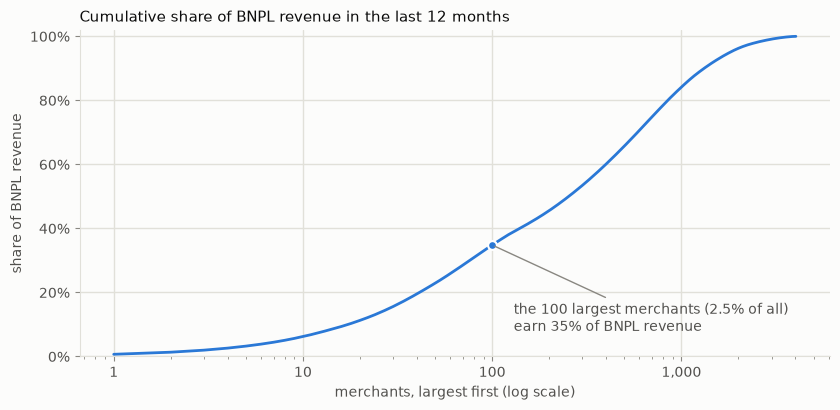

In [7]:
revenue_sorted = features["revenue_12m"].sort_values(ascending=False).to_numpy()
cumulative = revenue_sorted.cumsum() / revenue_sorted.sum()
top_100_share = cumulative[99]
half = int(np.searchsorted(cumulative, 0.5)) + 1

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(np.arange(1, len(cumulative) + 1), cumulative, color=BLUE)
ax.scatter([100], [top_100_share], s=40, color=BLUE, zorder=3, edgecolor="white", linewidth=1.5)
ax.annotate(f"the 100 largest merchants ({100 / len(features):.1%} of all)\nearn {top_100_share:.0%} of BNPL revenue",
            xy=(100, top_100_share), xytext=(130, 0.08), color=INK_SECONDARY,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_xscale("log")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(percent())
ax.set_ylim(0, 1.02)
ax.set_xlabel("merchants, largest first (log scale)")
ax.set_ylabel("share of BNPL revenue")
ax.set_title("Cumulative share of BNPL revenue in the last 12 months")
fig.tight_layout()
save(fig, "revenue_concentration")
plt.show()

Revenue is extremely concentrated. Merchant size varies by more than four orders of magnitude, from a handful of
sales a year to over 180,000, so size is the first thing any ranking has to capture. The number of customers and
the number of transactions are almost the same thing here: nearly every customer buys from a given merchant only
once (`transactions_per_customer` has a median of 1.01). The share of repeat customers mostly reflects size too
(see the correlations at the end).

### Take rate and fraud: the two other things that differ

`take_rate` runs from 0.1% to 7% and is set by the merchant's `revenue_level` (a = highest, e = lowest). A level-a
merchant earns the BNPL firm about 20x as much per dollar of sales as a level-e one. `fraud.ipynb` showed that
fraud follows order size. The chart checks that pattern merchant by merchant.

,merchants,min_take_rate,median_take_rate,max_take_rate,median_sales_12m
revenue_level,,,,,
a,1602,5.50,6.23,7.00,95745.29
b,1351,3.10,4.10,5.10,93126.19
c,922,1.40,2.25,3.10,77867.13
d,98,0.52,1.02,1.40,63685.05
e,53,0.10,0.31,0.48,56373.98


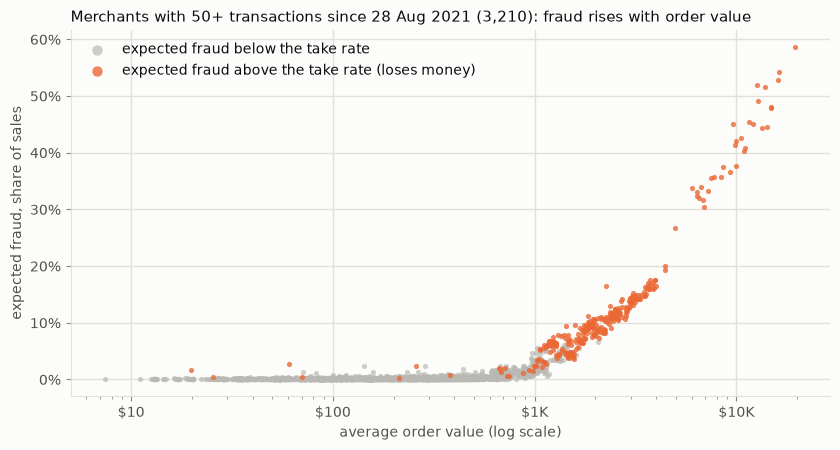

294 of these 3,210 merchants (9%) have expected fraud above their take rate


In [8]:
display(features.groupby("revenue_level").agg(merchants=("take_rate", "size"), min_take_rate=("take_rate", "min"),
                                              median_take_rate=("take_rate", "median"), max_take_rate=("take_rate", "max"),
                                              median_sales_12m=("sales_12m", "median")).round(2))

enough = features[features["transactions_since_snapshot"] >= 50]
loses = enough["fraud_rate"] > enough["take_rate"] / 100
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(enough.loc[~loses, "mean_order"], enough.loc[~loses, "fraud_rate"], s=14, color=CONTEXT_GREY,
           alpha=0.7, linewidth=0, label="expected fraud below the take rate")
ax.scatter(enough.loc[loses, "mean_order"], enough.loc[loses, "fraud_rate"], s=14, color=ORANGE,
           alpha=0.8, linewidth=0, label="expected fraud above the take rate (loses money)")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(money))
ax.yaxis.set_major_formatter(percent())
ax.set_xlabel("average order value (log scale)")
ax.set_ylabel("expected fraud, share of sales")
ax.legend(loc="upper left", markerscale=2)
ax.set_title(f"Merchants with 50+ transactions since 28 Aug 2021 ({len(enough):,}): fraud rises with order value")
fig.tight_layout()
save(fig, "fraud_vs_order_value")
plt.show()
print(f"{loses.sum():,} of these {len(enough):,} merchants ({loses.mean():.0%}) have expected fraud above their take rate")

Above an average order of roughly <span>\$1,000</span>, expected fraud climbs quickly. Most merchants whose average order is in
the thousands lose more to fraud than they earn in take rate. This is the strongest "don't onboard" signal in the
data.

### Growth and seasonality: the same for everyone

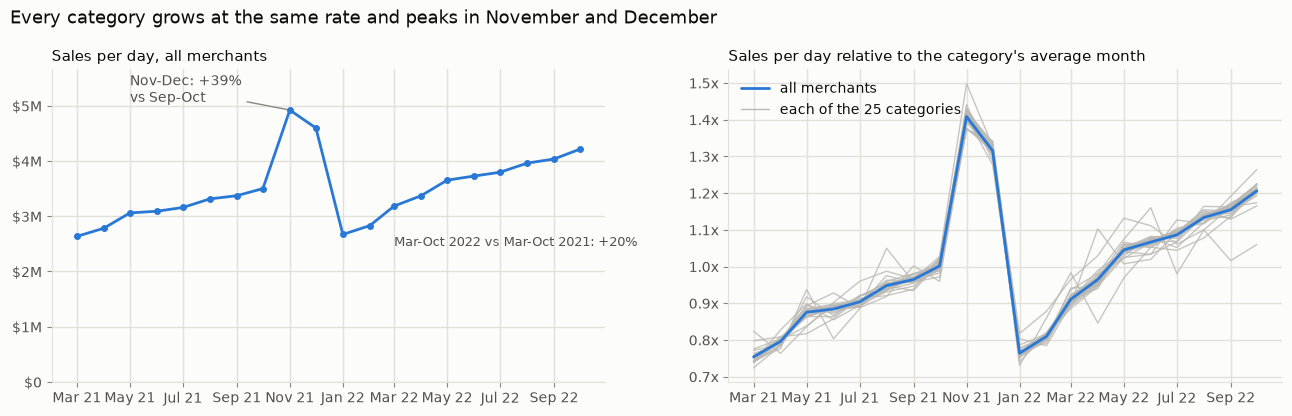

,count,10%,50%,90%
merchants by number of transactions,,,,
smallest 20%,773.0,-0.444,0.206,1.557
2nd,799.0,-0.137,0.204,0.676
3rd,805.0,0.022,0.206,0.424
4th,805.0,0.091,0.201,0.332
largest 20%,805.0,0.152,0.201,0.248


In [9]:
monthly = (daily.assign(month=daily["order_datetime"].dt.to_period("M"))
           .merge(features[["category"]], left_on="merchant_abn", right_index=True)
           .groupby(["month", "category"]).agg(sales=("sales", "sum"), days=("order_datetime", "nunique"))
           .reset_index())
monthly = monthly[monthly["month"].between(pd.Period("2021-03"), pd.Period("2022-10"))]  # skip the 1-day Feb 2021
monthly["sales_per_day"] = monthly["sales"] / monthly["days"]  # Oct 2022 only has 26 days of data
by_category = monthly.pivot(index="month", columns="category", values="sales_per_day")
index = by_category / by_category.mean()  # each category relative to its own average month
total = by_category.sum(axis=1)

overall_growth = this_year["sales"].sum() / last_year["sales"].sum() - 1
peak = total.loc[[pd.Period("2021-11"), pd.Period("2021-12")]].mean() / total.loc[pd.Period("2021-09"):pd.Period("2021-10")].mean() - 1

fig, (ax_total, ax_index) = plt.subplots(1, 2, figsize=(13, 4.2))
months = index.index.to_timestamp()
ax_total.plot(months, total, color=BLUE, marker="o", markersize=4)
ax_total.yaxis.set_major_formatter(FuncFormatter(money))
ax_total.set_ylim(0, total.max() * 1.15)
ax_total.set_title("Sales per day, all merchants")
ax_total.annotate(f"Nov-Dec: +{peak:.0%}\nvs Sep-Oct", xy=(pd.Timestamp("2021-11-01"), total.max()),
                  xytext=(pd.Timestamp("2021-05-01"), total.max() * 1.03), color=INK_SECONDARY,
                  arrowprops=dict(arrowstyle="-", color=MUTED))
ax_total.text(pd.Timestamp("2022-03-01"), total.max() * 0.5, f"Mar-Oct 2022 vs Mar-Oct 2021: +{overall_growth:.0%}",
              color=INK_SECONDARY, fontsize=9)
for category in index.columns:
    ax_index.plot(months, index[category], color=CONTEXT_GREY, linewidth=1, alpha=0.8)
ax_index.plot(months, total / total.mean(), color=BLUE, label="all merchants")
ax_index.plot([], [], color=CONTEXT_GREY, linewidth=1, label="each of the 25 categories")
ax_index.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}x"))
ax_index.legend(loc="upper left")
ax_index.set_title("Sales per day relative to the category's average month")
for ax in (ax_total, ax_index):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
suptitle(fig, "Every category grows at the same rate and peaks in November and December")
fig.tight_layout()
save(fig, "seasonality")
plt.show()

growth_by_size = (features[features["sales_growth"].notna()]
                  .groupby(pd.qcut(features["transactions"], 5, labels=["smallest 20%", "2nd", "3rd", "4th", "largest 20%"]),
                           observed=True)["sales_growth"]
                  .describe(percentiles=[0.1, 0.5, 0.9])[["count", "10%", "50%", "90%"]])
growth_by_size.index.name = "merchants by number of transactions"
display(growth_by_size.round(3))

- **The categories move together.** All 25 categories follow the same shape: a Christmas peak in November and
  December, a dip in January and February, and steady growth of about 20% a year. Seasonality and growth don't
  separate one category from another.
- **Merchants grow at the same rate too.** The median merchant grew about 20% in every size group. The spread in
  growth shrinks steadily as merchants get bigger: 80% of the largest fifth sit between +15% and +25%, while the
  smallest fifth range from -44% to +156%. That is the pattern random noise produces, not real differences in growth.
  `forecast.ipynb` tests whether a merchant's own growth rate predicts its future sales, and finds that it doesn't.

### Customers: every merchant's customers look like the whole customer base

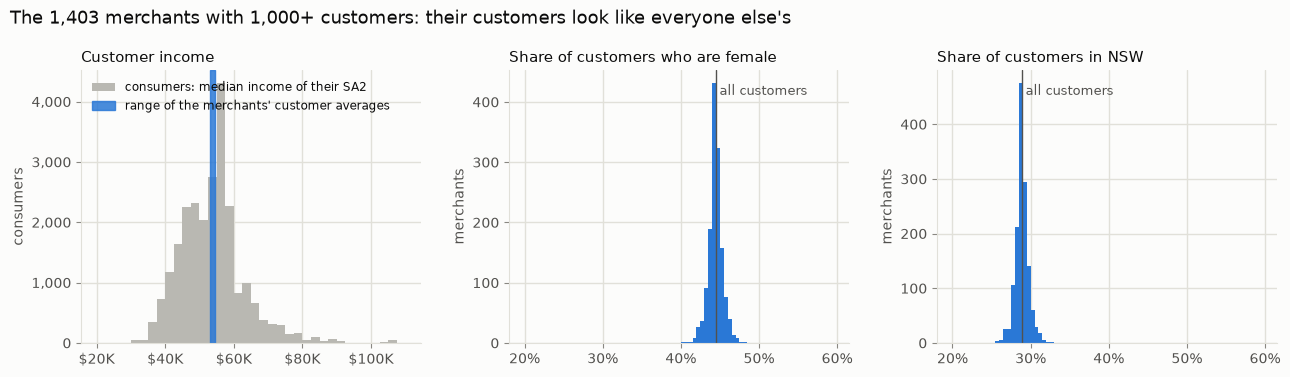

,min,50%,max
customer_median_income,53084.731,53726.848,54430.918
female_share,0.403,0.444,0.481
nsw_share,0.257,0.289,0.327
states_reached,8.000,8.000,8.000


In [10]:
consumer_income = (transactions.groupBy("user_id").agg(F.avg("median_income").alias("median_income"))
                   .toPandas()["median_income"])
big = features[features["customers"] >= 1000]
overall = transactions.agg(F.avg((F.col("gender") == "Female").cast("double")).alias("female"),
                           F.avg((F.col("state") == "NSW").cast("double")).alias("nsw")).first()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].hist(consumer_income, bins=np.arange(20_000, 110_001, 2_500), color=CONTEXT_GREY,
             label="consumers: median income of their SA2")
axes[0].axvspan(big["customer_median_income"].min(), big["customer_median_income"].max(), color=BLUE, alpha=0.85,
                label="range of the merchants' customer averages")
axes[0].xaxis.set_major_formatter(FuncFormatter(money))
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[0].set_ylabel("consumers")
axes[0].legend(loc="upper left", fontsize=8.5)
axes[0].set_title("Customer income")
for ax, column, value, title in [(axes[1], "female_share", overall["female"], "Share of customers who are female"),
                                 (axes[2], "nsw_share", overall["nsw"], "Share of customers in NSW")]:
    ax.hist(big[column], bins=np.arange(0.2, 0.6, 0.005), color=BLUE)
    ax.axvline(value, color=INK_SECONDARY, linewidth=1)
    ax.text(value, ax.get_ylim()[1] * 0.95, " all customers", color=INK_SECONDARY, fontsize=9, va="top")
    ax.xaxis.set_major_formatter(percent())
    ax.set_title(title)
    ax.set_ylabel("merchants")
suptitle(fig, f"The {len(big):,} merchants with 1,000+ customers: their customers look like everyone else's")
fig.tight_layout()
save(fig, "customer_demographics")
plt.show()

spread = big[["customer_median_income", "female_share", "nsw_share", "states_reached"]].describe().T[["min", "50%", "max"]]
display(spread.round(3))

Consumers live in areas with median incomes from about <span>\$22,000</span> to over <span>\$100,000</span>. Yet **every large merchant's
customers average out to almost exactly the same income** (between about <span>\$53,100</span> and <span>\$54,400</span>). They also have the
same gender mix (40-48% female) and the same share in each state (26-33% in NSW). Every one of them sells to all
eight states. Customers in this data choose merchants independently of where they live and what they earn.

So customer demographics and location **can't separate good merchants from bad ones**, and the ranking doesn't use
them. They are still shown on maps in `summary.ipynb`, to describe where BNPL customers are. (The data has no
merchant locations, only customer postcodes.)

### How the features relate to each other

In [11]:
correlation_columns = {"transactions_12m": "transactions", "customers_12m": "customers", "sales_12m": "sales",
                       "revenue_12m": "revenue", "take_rate": "take rate", "mean_order": "average order",
                       "fraud_rate": "fraud rate", "repeat_customer_share": "repeat customers",
                       "sales_growth": "growth", "sales_volatility": "volatility",
                       "customer_median_income": "customer income"}
established = features[features["transactions"] >= 100]
correlations = established[list(correlation_columns)].rename(columns=correlation_columns).corr(method="spearman")
display(correlations.round(2).style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:.2f}"))

,transactions,customers,sales,revenue,take rate,average order,fraud rate,repeat customers,growth,volatility,customer income
transactions,1.00,1.00,0.71,0.68,0.04,-0.36,-0.10,0.96,0.02,-0.97,0.04
customers,1.00,1.00,0.71,0.68,0.04,-0.36,-0.10,0.96,0.02,-0.97,0.04
sales,0.71,0.71,1.00,0.94,0.03,0.35,0.37,0.68,0.03,-0.70,0.03
revenue,0.68,0.68,0.94,1.00,0.32,0.32,0.34,0.65,0.03,-0.68,0.03
take rate,0.04,0.04,0.03,0.32,1.00,-0.02,-0.02,0.04,0.00,-0.05,-0.01
average order,-0.36,-0.36,0.35,0.32,-0.02,1.00,0.63,-0.35,0.01,0.33,0.00
fraud rate,-0.10,-0.10,0.37,0.34,-0.02,0.63,1.00,-0.10,0.03,0.10,-0.01
repeat customers,0.96,0.96,0.68,0.65,0.04,-0.35,-0.10,1.00,0.01,-0.93,0.03
growth,0.02,0.02,0.03,0.03,0.00,0.01,0.03,0.01,1.00,0.00,0.05
volatility,-0.97,-0.97,-0.70,-0.68,-0.05,0.33,0.10,-0.93,0.00,1.00,-0.04


Spearman (rank) correlations, for the merchants with at least 100 transactions:

- **Transactions and customers are the same measure** (1.00). **Repeat customers** (0.96) and **volatility** (-0.97)
  mostly measure size as well: a bigger merchant is more likely to see the same customer twice by chance, and a
  small merchant's monthly share swings with every extra order. **Sales and revenue** also rise with size (about
  0.7), but less tightly, because order values differ so much.
- **Fraud rate goes with average order** (0.63). Big-ticket merchants carry the fraud.
- **Take rate isn't related to size** (0.04): a merchant's revenue level doesn't tell you how big it is.
- **Growth and customer income aren't related to anything** (all within ±0.05). They are noise around values that
  every merchant shares.

## 4. SA2 summary for the maps

One row per SA2, with its population and the consumers who live there. `etl.ipynb` gives each postcode a single SA2
(the one holding most of its homes), so only some SA2s receive consumers, and PO-box postcodes have none. The maps in
`summary.ipynb` therefore group SA2s into the larger SA3 regions, which needs the population of **every** SA2. That is
read from the same ABS file as in `etl.ipynb`.

In [12]:
POPULATION_FILE = EXTERNAL / "population" / "32180DS0001_2022-23.xlsx"


def sa2_population():
    """Estimated resident population at 30 June 2023 for every SA2 (Tables 1-9 are one per state and territory)."""
    frames = []
    for table in range(1, 10):
        sheet = pd.read_excel(POPULATION_FILE, sheet_name=f"Table {table}", header=None, dtype=object)
        header_row = sheet.index[sheet.eq("SA2 code").any(axis=1)][0]
        code_col = sheet.columns[sheet.loc[header_row].eq("SA2 code")][0]
        assert sheet.loc[header_row - 1, code_col + 3] == 2023, "expected the ERP at 30 June 2023 column"
        body = sheet.loc[header_row + 1:, [code_col, code_col + 3]]
        body.columns = ["sa2_code", "population"]
        frames.append(body[body["sa2_code"].astype(str).str.fullmatch(r"\d{9}")])
    return pd.concat(frames, ignore_index=True).astype({"sa2_code": str, "population": "int64"})


since = F.col("order_datetime") >= SECOND_SNAPSHOT
sa2_consumers = (transactions.filter(F.col("sa2_code").isNotNull())
                 .groupBy("sa2_code")
                 .agg(F.countDistinct("user_id").alias("consumers"),
                      F.count("*").alias("transactions"),
                      F.sum("dollar_value").alias("sales"),
                      F.sum(F.when(since, F.col("dollar_value")).otherwise(0)).alias("sales_since_snapshot"),
                      F.sum(F.when(since, F.col("dollar_value") * F.col("fraud_probability")).otherwise(0))
                      .alias("expected_fraud_since_snapshot"),
                      F.max_by("median_income", "order_datetime").alias("median_income"))
                 .toPandas())
sa2 = sa2_population().merge(sa2_consumers.astype({"sa2_code": str}), on="sa2_code", how="left", validate="one_to_one")
assert sa2["consumers"].notna().sum() == len(sa2_consumers), "every SA2 with consumers has a population"
counts = ["consumers", "transactions", "sales", "sales_since_snapshot", "expected_fraud_since_snapshot"]
sa2[counts] = sa2[counts].fillna(0)
sa2["fraud_rate"] = sa2["expected_fraud_since_snapshot"] / sa2["sales_since_snapshot"].where(sa2["sales_since_snapshot"] > 0)
sa2.to_parquet(SA2_SUMMARY, index=False)
with_consumers = sa2[sa2["consumers"] > 0]
print(f"{len(sa2):,} SA2s, {len(with_consumers):,} of them with consumers; saved to {SA2_SUMMARY}")
print("Spearman correlation between an SA2's fraud rate and its median income (SA2s with 20+ consumers):",
      round(with_consumers[with_consumers["consumers"] >= 20][["fraud_rate", "median_income"]]
            .corr(method="spearman").iloc[0, 1], 3))

2,454 SA2s, 1,494 of them with consumers; saved to curated/sa2_summary.parquet
Spearman correlation between an SA2's fraud rate and its median income (SA2s with 20+ consumers): -0.027


**Is fraud concentrated in some areas?** Fraud rates differ between areas, but some difference is expected by chance
alone, because each area has only a few dozen consumers. To test this, consumers are shuffled between SA3 areas 500
times (SA3 = the first five digits of the SA2 code), and the spread of the area fraud rates is compared with the
real one.

In [13]:
consumer_fraud = (transactions.filter(since & F.col("sa2_code").isNotNull())
                  .groupBy("user_id", "sa2_code")
                  .agg(F.sum("dollar_value").alias("sales"),
                       F.sum(F.col("dollar_value") * F.col("fraud_probability")).alias("expected_fraud"))
                  .toPandas())
consumer_fraud["sa3_code"] = consumer_fraud["sa2_code"].astype(str).str[:5]


def spread_of_area_fraud_rates(sa3_codes):
    areas = consumer_fraud.groupby(sa3_codes).agg(sales=("sales", "sum"), fraud=("expected_fraud", "sum"),
                                                  consumers=("user_id", "size"))
    areas = areas[areas["consumers"] >= 20]
    return (areas["fraud"] / areas["sales"]).std()


rng = np.random.default_rng(0)
actual_spread = spread_of_area_fraud_rates(consumer_fraud["sa3_code"].to_numpy())
shuffled = np.array([spread_of_area_fraud_rates(rng.permutation(consumer_fraud["sa3_code"].to_numpy()))
                     for _ in range(500)])
print(f"spread (standard deviation) of SA3 fraud rates: actual {actual_spread:.2%}; "
      f"with consumers shuffled at random: {shuffled.mean():.2%} (95% of shuffles between "
      f"{np.percentile(shuffled, 2.5):.2%} and {np.percentile(shuffled, 97.5):.2%})")
print(f"share of shuffles with a spread at least as large as the actual one: {(shuffled >= actual_spread).mean():.0%}")

spread (standard deviation) of SA3 fraud rates: actual 0.78%; with consumers shuffled at random: 0.78% (95% of shuffles between 0.71% and 0.87%)
share of shuffles with a spread at least as large as the actual one: 52%


The real areas differ no more than randomly shuffled ones do, so **fraud has no geographic pattern**: where a
consumer lives says nothing about how likely they are to commit fraud. It isn't related to local income either
(rank correlation about 0, above).

In [14]:
n_merchants = len(features)
show_markdown(f"""
### Summary

**{n_merchants:,} merchants**, one row each, saved to `{MERCHANT_FEATURES}` with {features.shape[1]} features.

What separates merchants:
- **Size.** The 100 largest merchants earn **{top_100_share:.0%}** of the BNPL revenue of the last 12 months, and half
  of all revenue comes from the largest **{half}**.
- **Take rate**, which is set by `revenue_level`, from 0.1% (level e) to 7% (level a).
- **Fraud**, which follows order value: **{loses.sum():,}** of the {len(enough):,} merchants with enough data lose
  more to expected fraud than they earn in take rate.

What doesn't:
- **Growth and seasonality.** Sales grew **{overall_growth:.0%}** year on year, the same in every category and every
  size group, and every category peaks in Nov-Dec (+{peak:.0%}).
- **Customer demographics and location.** Every large merchant's customers mirror the whole customer base.
- **Repeat customers**, which mostly measures size.

These findings define the ranking: forecast each merchant's revenue (`forecast.ipynb`), subtract its expected fraud,
and rank by what's left (`ranking.ipynb`).
""")


### Summary

**4,026 merchants**, one row each, saved to `curated/merchant_features.parquet` with 40 features.

What separates merchants:
- **Size.** The 100 largest merchants earn **35%** of the BNPL revenue of the last 12 months, and half
  of all revenue comes from the largest **254**.
- **Take rate**, which is set by `revenue_level`, from 0.1% (level e) to 7% (level a).
- **Fraud**, which follows order value: **294** of the 3,210 merchants with enough data lose
  more to expected fraud than they earn in take rate.

What doesn't:
- **Growth and seasonality.** Sales grew **20%** year on year, the same in every category and every
  size group, and every category peaks in Nov-Dec (+39%).
- **Customer demographics and location.** Every large merchant's customers mirror the whole customer base.
- **Repeat customers**, which mostly measures size.

These findings define the ranking: forecast each merchant's revenue (`forecast.ipynb`), subtract its expected fraud,
and rank by what's left (`ranking.ipynb`).
